In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ["MPLCONFIGDIR"] = f"/tmp/{os.environ['USER']}_matplotlib_cache"

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [5]:
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import qmc
import healpy as hp
from cogwheel import gw_utils, utils

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
import helpers

warnings.simplefilter("ignore", RuntimeWarning)

### expected scaling $\mathcal L^\mathrm{max}_\mathrm{II} - \mathcal L^\mathrm{max}_\mathrm{I}\approx\ln\mathcal B^\mathrm{II}_\mathrm{I}$

For one detector, this is
$$
\ln\mathcal L^\mathrm{max}_\mathrm{II} - \ln\mathcal L^\mathrm{max}_\mathrm{I} = \frac{\rho^2}{2}\left(1 - \frac{\left(\mu\varepsilon\vert\vec F\vert^2\right)^2}{\left[\left(\varepsilon F_+\right)^2 + \left(\mu F_\times\right)^2\right]\left[\left(\varepsilon F_\times\right)^2 + \left(\mu F_+\right)^2\right]}\right)
$$
with $\mu\equiv\cos\iota$ and $\varepsilon\equiv(1+\mu^2)/2$.

$$
\ln\mathcal L^\mathrm{max}_\mathrm{II} - \ln\mathcal L^\mathrm{max}_\mathrm{I} = \frac{\rho^2}{2}\left(1 - \frac{\left(\mu\varepsilon\sum_d \vert\vec F^{(d)}\vert^2\langle H^{(d)}|H^{(d)}\rangle\right)^2}{\sum_d\left[\left(\varepsilon F_+^{(d)}\right)^2 + \left(\mu F_\times^{(d)}\right)^2\right]\langle H^{(d)}|H^{(d)}\rangle\sum_d\left[\left(\varepsilon F_\times^{(d)}\right)^2 + \left(\mu F_+^{(d)}\right)^2\right]\langle H^{(d)}|H^{(d)}\rangle}\right)
$$
with $\mu\equiv\cos\iota$, $\varepsilon\equiv(1+\mu^2)/2$, and $H^{(d)}\equiv S_m^{(d)} h_m^{(d)}$

### one detector

In [25]:
# check that my formula matches Javier's
def my_formula(Fplus, Fcross, mu):

    eps = (1 + mu**2) / 2
    num = (mu * eps * (Fplus**2 + Fcross**2))**2

    denom1 = (eps * Fplus)**2 + (mu * Fcross)**2
    denom2 = (eps * Fcross)**2 + (mu * Fplus)**2

    return 0.5 * (1 - num / (denom1 * denom2))

def formula(fp, fc, mu):
    return 0.5 * ((fc**2*fp**2*(-1 + mu**2)**4)
            /((4*fp**2*mu**2 + fc**2*(1 + mu**2)**2)*(4*fc**2*mu**2 + fp**2*(1 + mu**2)**2)))

In [26]:
mu = 0.5
psi = 1.0
lon, sindec = qmc.scale(qmc.Halton(2).random(1000), l_bounds=(-np.pi, -1), u_bounds=(np.pi, 1)).T
dec = np.arcsin(sindec)
fp0, fc0 = gw_utils.get_fplus_fcross_0('H', lon, dec)[:, 0].T

In [28]:
# does Javier's version of the formula match my own?
a = my_formula(fp0, fc0, mu)
b = formula(fp0, fc0, mu)
np.allclose(a, b)

True

In [29]:
c = np.cos(2*psi)
s = np.sin(2*psi)
rot = ((c, -s),
       (s, c))
fp1, fc1 = np.matmul(rot, (fp0, fc0))

In [32]:
# calculate the mismatch
z0 = formula(fp0, fc0, mu)
z1 = formula(fp1, fc1, mu)

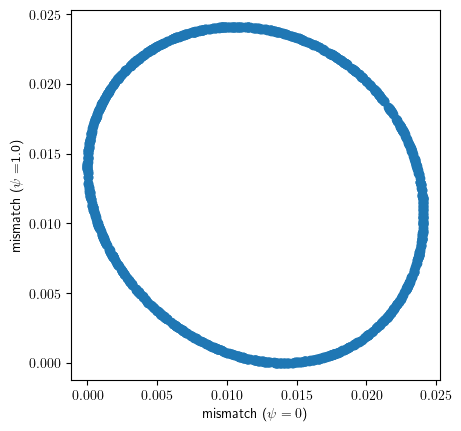

In [33]:
# plot
plt.figure()
plt.scatter(z0, z1)
plt.xlabel(r'mismatch ($\psi = 0$)')
plt.ylabel(r'mismatch ($\psi = $'f'{psi})')
plt.gca().set_aspect('equal')

In [34]:
# what if we do the same thing but in RA and Dec ? rather than lon and lat relative to the detector?
tgps = 0.
fplus0, fcross0 = np.array([
    gw_utils.fplus_fcross('H', lon_, dec_, 0., tgps).T for (lon_, dec_) in zip(lon, dec)
]).T
fplus1, fcross1 = np.array([
    gw_utils.fplus_fcross('H', lon_, dec_, psi, tgps).T for (lon_, dec_) in zip(lon, dec)
]).T
# calculate the mismatch
z0 = formula(fplus0, fcross0, mu)
z1 = formula(fplus1, fcross1, mu)

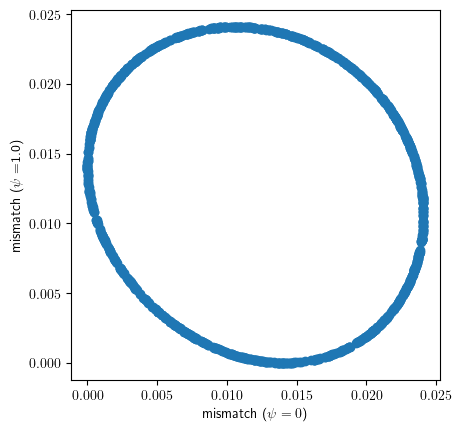

In [35]:
# plot
plt.figure()
plt.scatter(z0, z1)
plt.xlabel(r'mismatch ($\psi = 0$)')
plt.ylabel(r'mismatch ($\psi = $'f'{psi})')
plt.gca().set_aspect('equal')

In [39]:
# hmm at least this all matches Javier so far. let's do this on a healpix grid
nside = 32
ipix = np.arange(hp.nside2npix(nside))
theta, phi = hp.pixelfunc.pix2ang(nside, ipix)  # theta \in [0, π] and phi \in [0, 2π]
# convert (theta, phi) -> (RA, Dec)
ra, dec = theta, phi - np.pi / 2
detector_names = ('H')
# pick a time and polarization angle
tgps = 0.
fplus0, fcross0 = np.array([
    gw_utils.fplus_fcross(detector_names, ra_, dec_, 0., tgps).T for (ra_, dec_) in zip(ra, dec)
]).T
# and another angle
fplus1, fcross1 = np.array([
    gw_utils.fplus_fcross(detector_names, ra_, dec_, psi, tgps).T for (ra_, dec_) in zip(ra, dec)
]).T
# now compute the mismatches at (RA,Dec) for these two polarizations
mismatch0 = formula(fplus0, fcross0, mu)[0,:]
mismatch1 = formula(fplus1, fcross1, mu)[0,:]

In [41]:
# are these the same?
np.allclose(mismatch0, mismatch1)

False

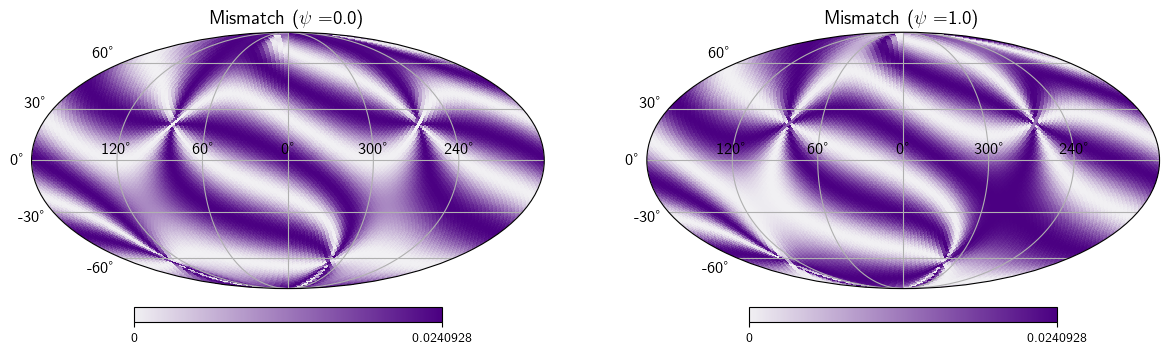

In [40]:
# plot
fig = plt.figure(figsize=(12,4))
for i, (psi_, mismatch) in enumerate(zip([0., psi], [mismatch0, mismatch1])):
    hp.projview(mismatch, sub=(1, 2, i+1), cmap=sns.light_palette('indigo', as_cmap=True), coord=['C'], title=r'Mismatch ($\psi =$'f'{psi_})',
                min=0., max=None, graticule=True, graticule_labels=True)

#### antenna response functions

In [4]:
nside = 32
ipix = np.arange(hp.nside2npix(nside))
theta, phi = hp.pixelfunc.pix2ang(nside, ipix)  # theta \in [0, π] and phi \in [0, 2π]
# convert (theta, phi) -> (RA, Dec)
ra, dec = theta, phi - np.pi / 2
detector_names = ('H', 'L', 'V')
# pick a time and polarization angle
tgps = 0.
psi = 0.
fplus, fcross = np.array([
    gw_utils.fplus_fcross(detector_names, ra_, dec_, psi, tgps).T for (ra_, dec_) in zip(ra, dec)
]).T

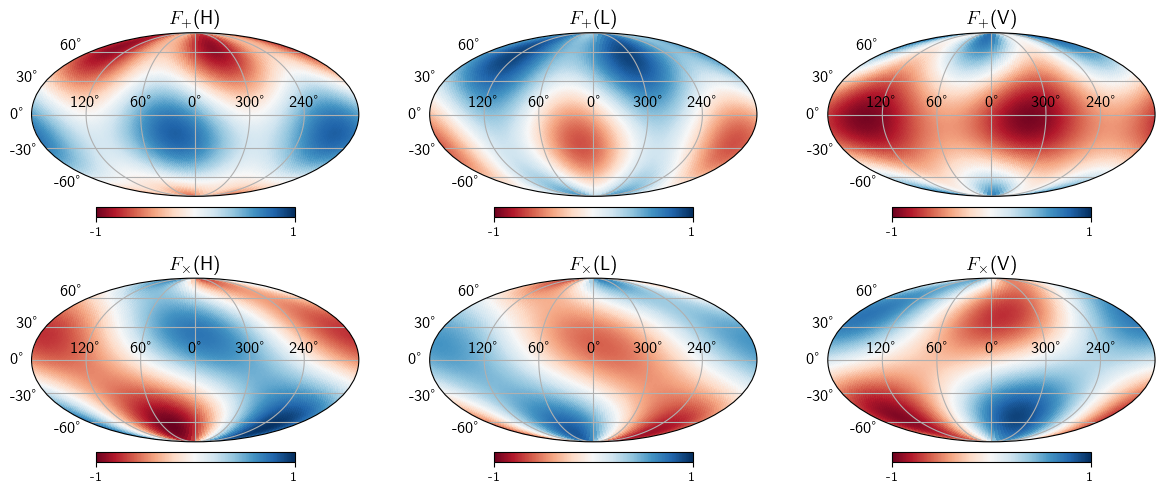

In [5]:
fig = plt.figure(figsize=(12,5))
for i, (fstr, farr) in enumerate(zip([r'$F_+$', r'$F_\times$'], [fplus, fcross])):
    for j, (det_name, f_det) in enumerate(zip(detector_names, farr)):
        hp.projview(f_det, sub=(2, 3, len(farr) * i + j+1 ), cmap='RdBu', coord=['C'], title=fstr + f'({det_name})',
                    min=-1., max=1., graticule=True, graticule_labels=True)

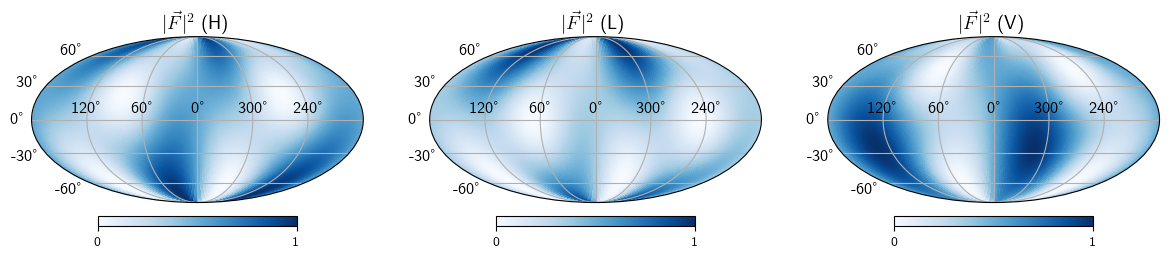

In [6]:
# what about the norm squared?
fsq = fplus**2 + fcross**2
fig = plt.figure(figsize=(12,3))
for i, (det_name, fsq_det) in enumerate(zip(detector_names, fsq)):
    hp.projview(fsq_det, fig=fig, cmap='Blues', coord=['C'], title=r'$|\vec F|^2$'f' ({det_name})', sub=(1, 3, i+1),
                min=0., max=1., graticule=True, graticule_labels=True)

In [7]:
nside = 32
ipix = np.arange(hp.nside2npix(nside))
theta, phi = hp.pixelfunc.pix2ang(nside, ipix)  # theta \in [0, π] and phi \in [0, 2π]
# convert (theta, phi) -> (RA, Dec)
ra, dec = theta, phi - np.pi / 2
detector_names = ('H', 'L', 'V')
# pick a time and polarization angle
tgps = 0.
psi = np.pi / 4
fplus, fcross = np.array([
    gw_utils.fplus_fcross(detector_names, ra_, dec_, psi, tgps).T for (ra_, dec_) in zip(ra, dec)
]).T

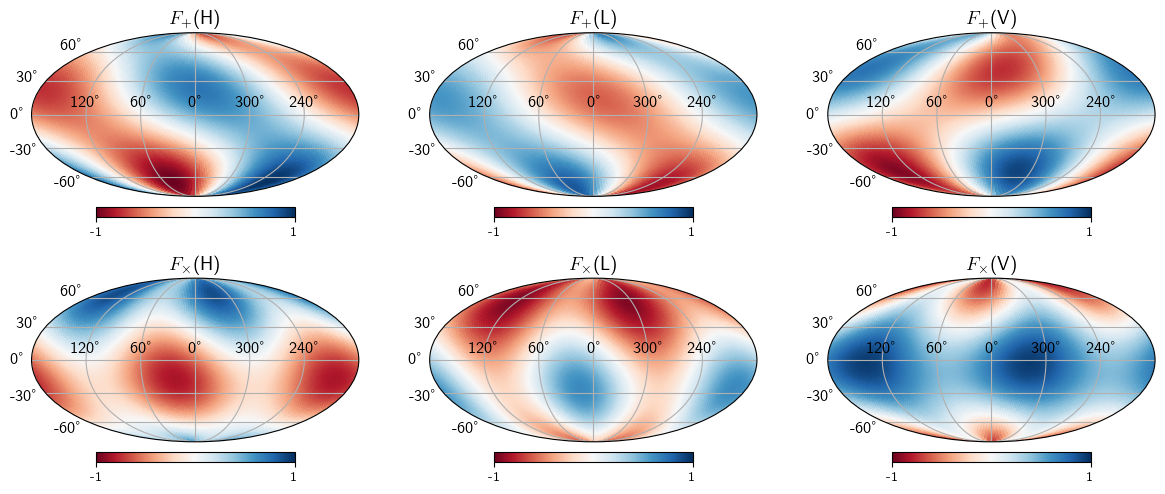

In [8]:
fig = plt.figure(figsize=(12,5))
for i, (fstr, farr) in enumerate(zip([r'$F_+$', r'$F_\times$'], [fplus, fcross])):
    for j, (det_name, f_det) in enumerate(zip(detector_names, farr)):
        hp.projview(f_det, sub=(2, 3, len(farr) * i + j+1 ), cmap='RdBu', coord=['C'], title=fstr + f'({det_name})',
                    min=-1., max=1., graticule=True, graticule_labels=True)

#### construct $H = S_m h_m$

In [9]:
# load a sampler
approximant = 'IMRPhenomXPHM'
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12
idx = 0
eventname = f'GW{seed}_{idx}'
eventdir = os.path.join(resdir, eventname)
sampler = utils.read_json(os.path.join(eventdir, 'run_0', 'Sampler.json'))

In [10]:
like = sampler.posterior.likelihood
# which harmonic modes are present in the signal?
harmonic_modes = like.waveform_generator.harmonic_modes
m_arr = like.waveform_generator.m_arr
print(f"harmonic modes: ", harmonic_modes)
# get the injected parameters
par_dic = sampler.posterior.likelihood.event_data.injection['par_dic']
# waveform (frequency domain) in each detector
h = sampler.posterior.likelihood._get_h_f(par_dic, by_m=True)

harmonic modes:  [(2, 2), (2, 1), (3, 3), (3, 2), (4, 4)]


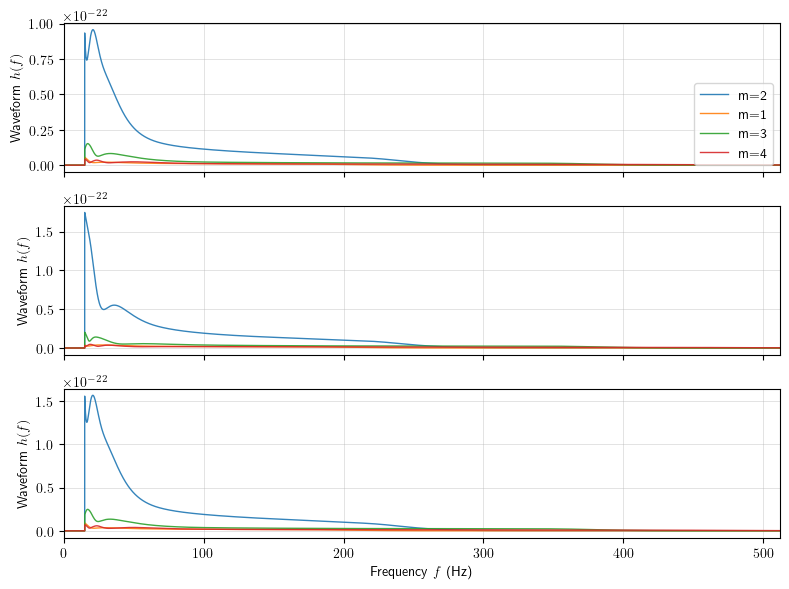

In [11]:
# plot these
fig, axs = plt.subplots(3, 1, figsize=(8,6), tight_layout=True)
for i, ax in enumerate(axs):
    for j, m in enumerate(m_arr):
        ax.plot(like.event_data.frequencies, np.abs(h[j,i]), alpha=0.9, lw=1, label=f'm={m}')
    ax.grid(alpha=0.5, lw=0.5)
    ax.set_ylabel(r'Waveform $h(f)$')
    ax.set_xlim(0., like.event_data.frequencies.max())
    if ax is not axs[-1]:
        ax.set_xticklabels([])
axs[-1].set_xlabel(r'Frequency $f$ (Hz)')
axs[0].legend(loc=4)

### expected mismatch: randomly sampled $(\mathrm{RA},\mathrm{Dec},\psi)$

In [42]:
# okay but we could also try this uniformly across the sky using healpix
nside = 16
ipix = np.arange(hp.nside2npix(nside))
theta, phi = hp.pixelfunc.pix2ang(nside, ipix)  # theta \in [0, π] and phi \in [0, 2π]
# convert (theta, phi) -> (RA, Dec)
ra, dec = theta, phi - np.pi / 2

In [43]:
# get HH from one of the injections
idx = 0
samples_dir = f'/home/abbye.williams/GWPE/data/injections/Halton/IMRPhenomXPHM/IntrinsicLVCPrior/GW12_{idx}/run_0'
sampler = utils.read_json(os.path.join(samples_dir, 'Sampler.json'))
HH = helpers.compute_HH(sampler.posterior.likelihood)
# get the polarization from the injection
# psi = sampler.posterior.likelihood.event_data.injection['par_dic']['psi']

In [44]:
iotas = np.arange(0., np.pi / 2 + 0.001, 0.001 * np.pi)
mus = np.cos(iotas)

detector_names = ('H')
tgps = 0.
psi = 0.

# compute the expected mismatch as a function of inclination for each of these locations

fplus, fcross = np.array([
    gw_utils.fplus_fcross(detector_names, ra_, dec_, psi, tgps).T for (ra_, dec_) in zip(ra, dec)
]).T
mismatches_arr = np.empty((len(ra), len(mus)))
for i, (fplus_, fcross_) in enumerate(zip(fplus.T, fcross.T)):
    mismatches_arr[i] = np.array([
        helpers.expected_mismatch_with_HH(fplus_, fcross_, mu, HH) for mu in mus
    ])
mismatch_dic = {
    'avg' : np.mean(mismatches_arr, axis=0),
    'min' : np.min(mismatches_arr, axis=0),
    'max' : np.max(mismatches_arr, axis=0)
}

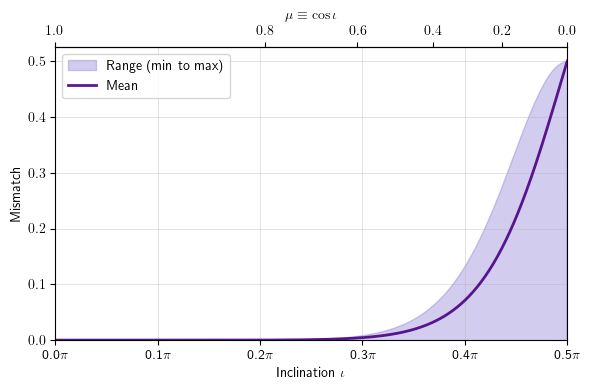

In [45]:
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
xticks = np.arange(0., 0.51, 0.1) * np.pi
xticklabels = [f'{x / np.pi:.1f}'r'$\pi$' for x in xticks]

ax.fill_between(iotas, mismatch_dic['min'], mismatch_dic['max'],
                color='slateblue', alpha=0.3, label='Range (min to max)')
ax.plot(iotas, mismatch_dic['avg'], c='indigo', lw=2, alpha=0.9, label='Mean')

ax.grid(alpha=0.5, lw=0.5)
ax.set_xlim(0., np.pi/2)
ax.set_ylim(0., None)
ax.set_xticks(xticks, labels=xticklabels)
ax.set_xlabel(r'Inclination $\iota$')
secax = ax.secondary_xaxis('top', functions=(lambda x: np.cos(x), lambda x: np.arccos(x)))
secax.set_xlabel(r'$\mu\equiv\cos\iota$')
ax.set_ylabel(r'Mismatch')# $\ln\mathcal B / \rho^2$')
ax.legend()

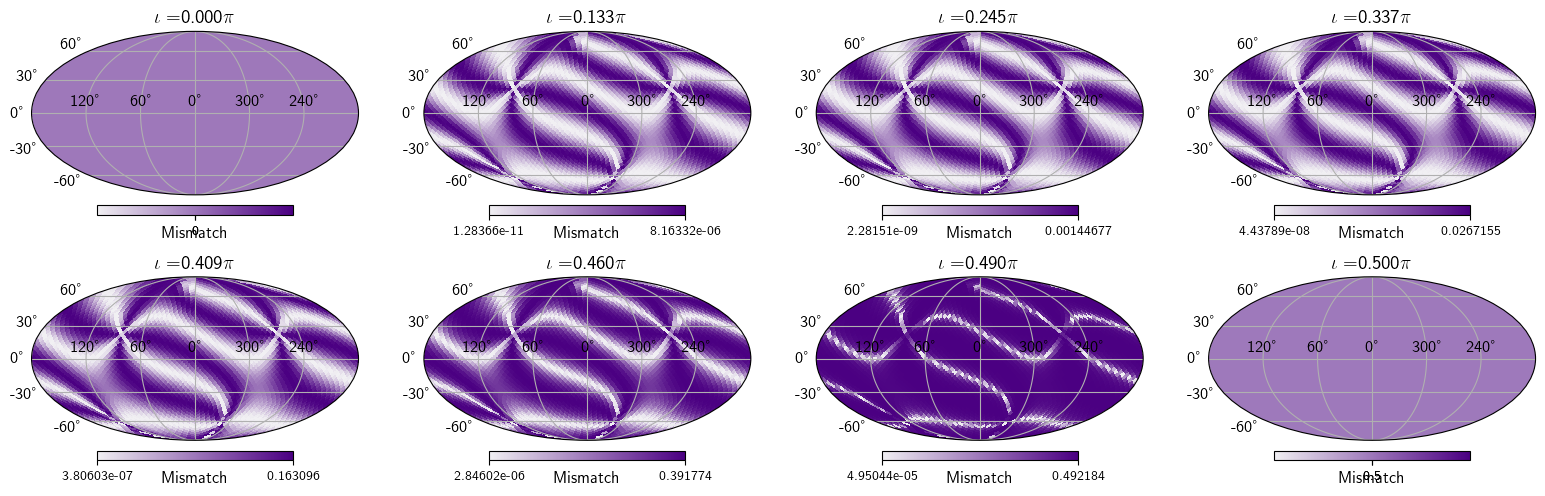

In [46]:
# let's get a sample of inclinations from a power law
N = 8
power = 2
t = np.linspace(0, 1, N)    # evenly spaced
n = len(iotas) - 1
iiotas = n - (n * (1 - t)**power).astype(int)
# plot
fig = plt.figure(figsize=(16,5))
for i, iiota in enumerate(iiotas):
    title = r'$\iota = $'f'{iotas[iiota] / np.pi:.3f}'r'$\pi$'
    cmap = sns.light_palette('indigo', as_cmap=True)
    hp.projview(mismatches_arr[:,iiota], coord=['C'],
                cmap=cmap, sub=(2,4,i+1), fig=fig,
                graticule=True, graticule_labels=True, unit='Mismatch', title=title)

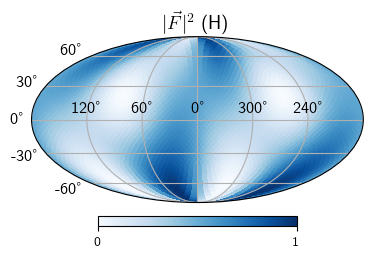

In [47]:
fsq = fplus**2 + fcross**2
fig = plt.figure(figsize=(12,3))
for i, (det_name, farr) in enumerate(zip(detector_names, fsq)):
    hp.projview(farr, cmap='Blues', fig=fig, sub=(1, 3, i+1), title=r'$|\vec F|^2$'f' ({det_name})', graticule=True, graticule_labels=True, min=0., max=1.)

In [52]:
# try different polarizations, fixing mu
mu = 0.5

detector_names = ('H')
tgps = 0.
psis = np.arange(0., np.pi + 0.01, 0.2 * np.pi)

mismatch_dics = {}
# compute the expected mismatch as a function of inclination for each of these locations
for psi in psis:
    fplus, fcross = np.array([
        gw_utils.fplus_fcross(detector_names, ra_, dec_, psi, tgps).T for (ra_, dec_) in zip(ra, dec)
    ]).T
    mismatches_arr = np.array([
        helpers.expected_mismatch_with_HH(fplus_, fcross_, mu, HH) for fplus_, fcross_ in zip(fplus.T, fcross.T)
    ])
    mismatch_dic = {
        'arr' : mismatches_arr,
        'avg' : np.mean(mismatches_arr, axis=0),
        'min' : np.min(mismatches_arr, axis=0),
        'max' : np.max(mismatches_arr, axis=0)
    }
    mismatch_dics[psi] = mismatch_dic
    print(f"psi = {psi / np.pi:.1f}π: \tavg = {mismatch_dic['avg']:.5f}, min = {mismatch_dic['min']:.5f}, max = {mismatch_dic['max']:.5f}")

psi = 0.0π: 	avg = 0.01202, min = 0.00000, max = 0.02409
psi = 0.2π: 	avg = 0.01214, min = 0.00000, max = 0.02409
psi = 0.4π: 	avg = 0.01234, min = 0.00000, max = 0.02409
psi = 0.6π: 	avg = 0.01234, min = 0.00000, max = 0.02409
psi = 0.8π: 	avg = 0.01214, min = 0.00000, max = 0.02409
psi = 1.0π: 	avg = 0.01202, min = 0.00000, max = 0.02409


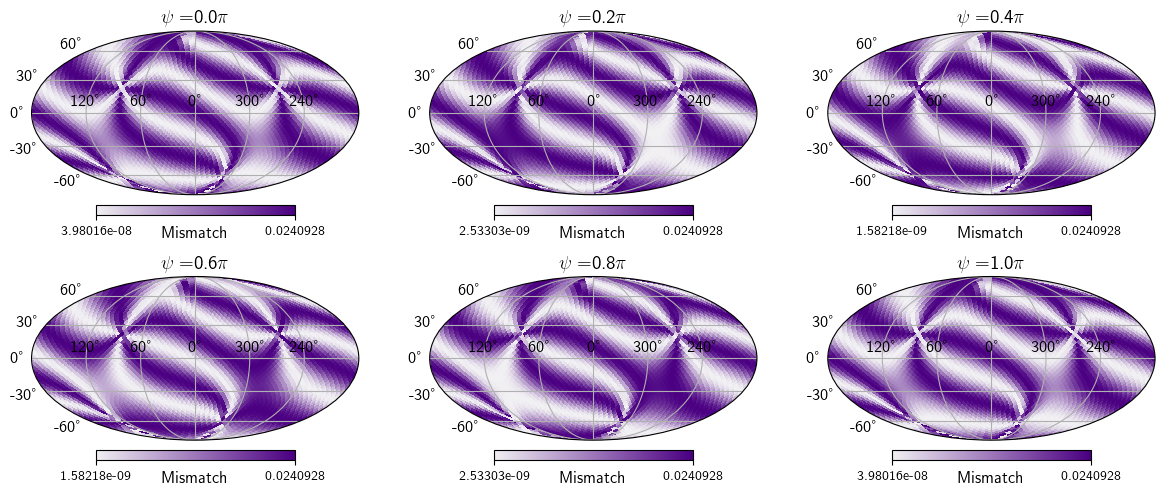

In [54]:
# sky plots
fig = plt.figure(figsize=(12,5))
cmap = sns.light_palette('indigo', as_cmap=True)
for i, psi in enumerate(psis):
    title = r'$\psi = $'f'{psi / np.pi:.1f}'r'$\pi$'
    hp.projview(mismatch_dics[psi]['arr'], coord=['C'],
                cmap=cmap, sub=(2,3,i+1), fig=fig,
                graticule=True, graticule_labels=True, unit='Mismatch', title=title)